# VQ-VAE

Discrete-latent autoencoder on LFW faces.

Switch between the two codebook update rules with a single flag (`use_ema`):
- `use_ema=False` \u2014 original VQ-VAE, codebook trained by gradient (two-term loss).
- `use_ema=True`  \u2014 codebook updated by EMA, more robust against codebook collapse.

Everything below is identical for both, thanks to the shared interface (`encode`, `quantize.init_from_data`, `quantize.get_code_indices`).

In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

from vq_vae import TinnyVQVAE, loss_vq_vae

In [2]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
    
print(f'Device is {device}')

Device is cuda


In [3]:
PATH_TO_PHOTOS = '../archive/lfw-deepfunneled'

paths = []
for dirpath, _, filenames in os.walk(PATH_TO_PHOTOS):
    for fname in filenames:
        if fname.endswith('.jpg'):
            paths.append(os.path.join(dirpath, fname))

all_photos = []
for path in paths:
    with open(path, 'rb') as f:
        image = np.array(Image.open(f).convert('RGB'))[80:-80, 80:-80]
        image = np.array(Image.fromarray(image).resize((64, 64), Image.Resampling.LANCZOS))
        all_photos.append(image)

print(f'Photos uploaded: {len(all_photos)}')

Photos uploaded: 13233


In [4]:
train_photos, val_photos = train_test_split(all_photos, train_size=0.9, shuffle=True)
train_loader = torch.utils.data.DataLoader(train_photos, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_photos, batch_size=32)

In [5]:
USE_EMA = False # True = EMA codebook, False = gradient codebook

N_E = 1024
model = TinnyVQVAE(n_e=N_E, e_dim=8, use_ema=USE_EMA).to(device)

model.eval()
with torch.no_grad():
    sample_batch = next(iter(train_loader)).permute(0, 3, 1, 2).to(device).to(torch.float32) / 255
    z_e, _ = model.encode(sample_batch)  # (BS*H*W, e_dim)
    perm = torch.randperm(z_e.shape[0])[:model.quantize.n_e]
    model.quantize.init_from_data(z_e[perm])
    print('Codebook initialized from data')


Codebook initialized from data


In [6]:
n_epochs = 100
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_mse_losses, train_vq_losses = [], []
val_mse_losses,   val_vq_losses   = [], []

for epoch in tqdm(range(n_epochs)):
    model.train()
    epoch_mse, epoch_vq = 0.0, 0.0
    for batch in train_loader:
        batch = batch.permute(0, 3, 1, 2).to(device).to(torch.float32) / 255
        optimizer.zero_grad()
        reconstruction, vq_loss = model(batch)
        loss = loss_vq_vae(batch, reconstruction, vq_loss)
        loss.backward()
        optimizer.step()
        epoch_mse += (loss - vq_loss).item()            # mse = loss - vq
        epoch_vq  += vq_loss.item()
    train_mse_losses.append(epoch_mse / len(train_loader))
    train_vq_losses.append(epoch_vq  / len(train_loader))

    model.eval()
    epoch_mse, epoch_vq = 0.0, 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.permute(0, 3, 1, 2).to(device).to(torch.float32) / 255
            reconstruction, vq_loss = model(batch)
            loss = loss_vq_vae(batch, reconstruction, vq_loss)
            epoch_mse += (loss - vq_loss).item()
            epoch_vq  += vq_loss.item()
    val_mse_losses.append(epoch_mse / len(val_loader))
    val_vq_losses.append(epoch_vq  / len(val_loader))

  0%|          | 0/100 [00:00<?, ?it/s]

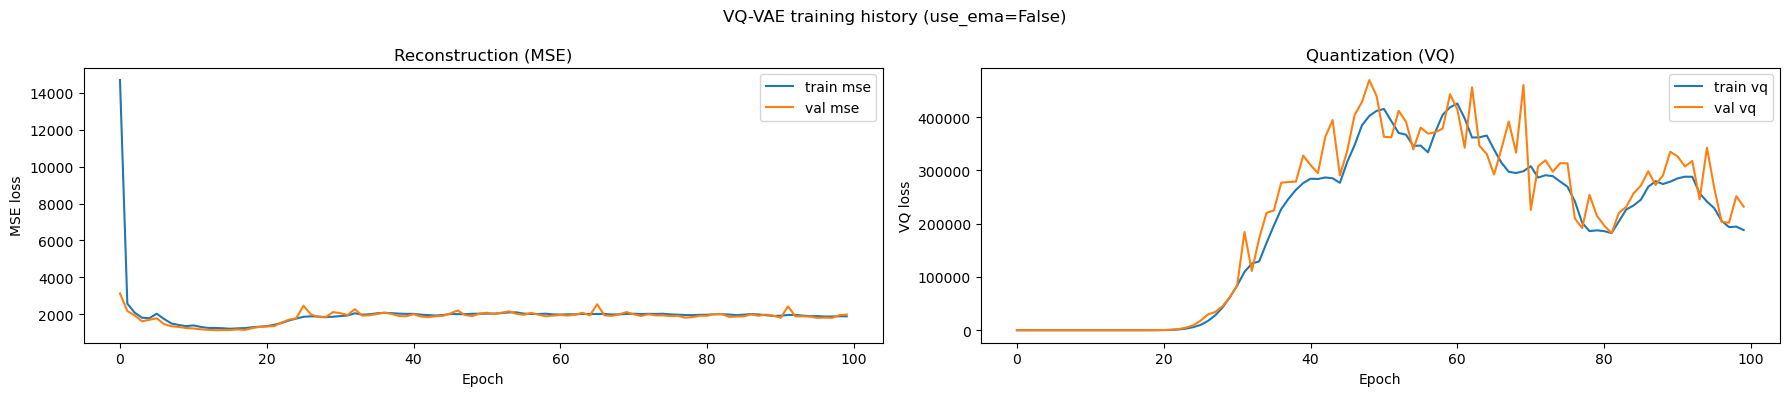

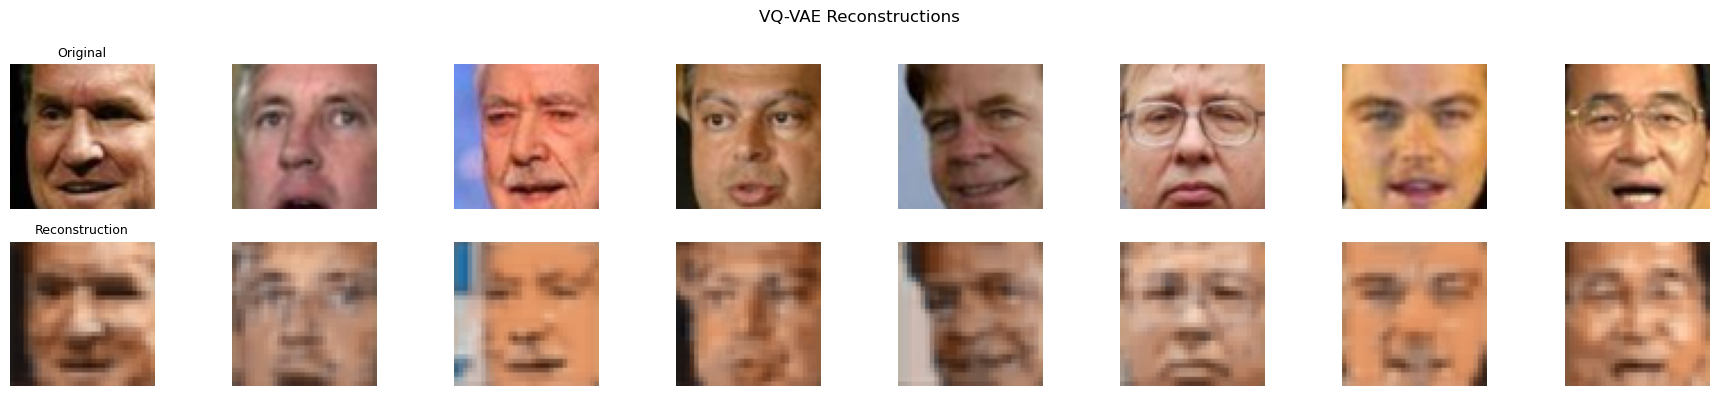

In [7]:
fig, (ax_mse, ax_vq) = plt.subplots(1, 2, figsize=(18, 4))

ax_mse.plot(train_mse_losses, label='train mse')
ax_mse.plot(val_mse_losses,   label='val mse')
ax_mse.set_xlabel('Epoch')
ax_mse.set_ylabel('MSE loss')
ax_mse.set_title('Reconstruction (MSE)')
ax_mse.legend()

ax_vq.plot(train_vq_losses, label='train vq')
ax_vq.plot(val_vq_losses,   label='val vq')
ax_vq.set_xlabel('Epoch')
ax_vq.set_ylabel('VQ loss')
ax_vq.set_title('Quantization (VQ)')
ax_vq.legend()

fig.suptitle(f"VQ-VAE training history (use_ema={USE_EMA})")
plt.tight_layout()
plt.show()

model.eval()
with torch.no_grad():
    sample_batch = next(iter(val_loader)).permute(0, 3, 1, 2).to(device).to(torch.float32) / 255
    reconstruction, _ = model(sample_batch)

n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(18, 4))
for i in range(n_show):
    axes[0, i].imshow(sample_batch[i].cpu().permute(1, 2, 0).numpy().clip(0, 1))
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstruction[i].cpu().permute(1, 2, 0).numpy().clip(0, 1))
    axes[1, i].axis('off')
axes[0, 0].set_title('Original', fontsize=9)
axes[1, 0].set_title('Reconstruction', fontsize=9)
plt.suptitle('VQ-VAE Reconstructions')
plt.tight_layout()
plt.show()

This can be explained by the fact that we don't constrain the norm of the codebook vectors, so at some point they start "drifting" apart. However, relative to the encoder vectors, the nearest codebook vectors stay the same — they just end up farther away in space. That's why vq_loss grows while the decoding quality doesn't change and mse_loss stays just as low.

Codebook size: 1024
Codes in use:  25


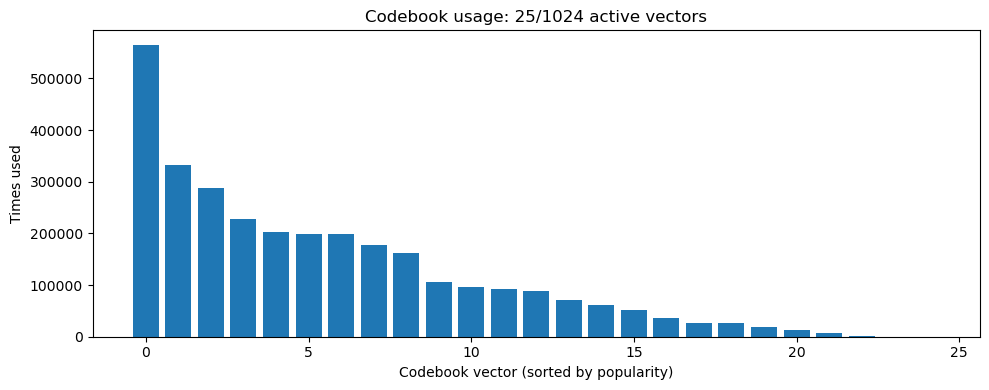

Top-10 codes take 80.6% of all assignments
Median uses: 87794 | max: 565006 | min: 1


In [8]:
model.eval()
all_indices = []
with torch.no_grad():
    for batch in train_loader:
        batch = batch.permute(0, 3, 1, 2).to(device).to(torch.float32) / 255
        z_e, _ = model.encode(batch)
        indices = model.quantize.get_code_indices(z_e)
        all_indices.append(indices.cpu().numpy())
all_indices = np.concatenate(all_indices)

n_e = model.quantize.n_e
unique, counts = np.unique(all_indices, return_counts=True)
print(f'Codebook size: {n_e}')
print(f'Codes in use:  {len(unique)}')

counts_sorted = np.sort(counts)[::-1]
plt.figure(figsize=(10, 4))
plt.bar(range(len(counts_sorted)), counts_sorted)
plt.xlabel('Codebook vector (sorted by popularity)')
plt.ylabel('Times used')
plt.title(f'Codebook usage: {len(unique)}/{n_e} active vectors')
plt.tight_layout()
plt.show()

print(f'Top-10 codes take {counts_sorted[:10].sum() / counts.sum() * 100:.1f}% of all assignments')
print(f'Median uses: {np.median(counts):.0f} | max: {counts.max()} | min: {counts.min()}')

## EMAVectorizer

In [9]:
USE_EMA = True # True = EMA codebook, False = gradient codebook 

N_E = 1024
model = TinnyVQVAE(n_e=N_E, e_dim=8, use_ema=USE_EMA).to(device)

# Initialize the codebook from real encoder outputs (reduces dead codes).
# init_from_data() handles the variant-specific bookkeeping (EMA also syncs ema_w / cluster_size).

model.eval()
with torch.no_grad():
    sample_batch = next(iter(train_loader)).permute(0, 3, 1, 2).to(device).to(torch.float32) / 255
    z_e, _ = model.encode(sample_batch)  # (BS*H*W, e_dim)
    perm = torch.randperm(z_e.shape[0])[:model.quantize.n_e]
    model.quantize.init_from_data(z_e[perm])
    print('Codebook initialized from data')


Codebook initialized from data


In [10]:
n_epochs = 100
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_mse_losses, train_vq_losses = [], []
val_mse_losses,   val_vq_losses   = [], []

for epoch in tqdm(range(n_epochs)):
    model.train()
    epoch_mse, epoch_vq = 0.0, 0.0
    for batch in train_loader:
        batch = batch.permute(0, 3, 1, 2).to(device).to(torch.float32) / 255
        optimizer.zero_grad()
        reconstruction, vq_loss = model(batch)
        loss = loss_vq_vae(batch, reconstruction, vq_loss)
        loss.backward()
        optimizer.step()
        epoch_mse += (loss - vq_loss).item()            # mse = loss - vq
        epoch_vq  += vq_loss.item()
    train_mse_losses.append(epoch_mse / len(train_loader))
    train_vq_losses.append(epoch_vq  / len(train_loader))

    model.eval()
    epoch_mse, epoch_vq = 0.0, 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.permute(0, 3, 1, 2).to(device).to(torch.float32) / 255
            reconstruction, vq_loss = model(batch)
            loss = loss_vq_vae(batch, reconstruction, vq_loss)
            epoch_mse += (loss - vq_loss).item()
            epoch_vq  += vq_loss.item()
    val_mse_losses.append(epoch_mse / len(val_loader))
    val_vq_losses.append(epoch_vq  / len(val_loader))



  0%|          | 0/100 [00:00<?, ?it/s]

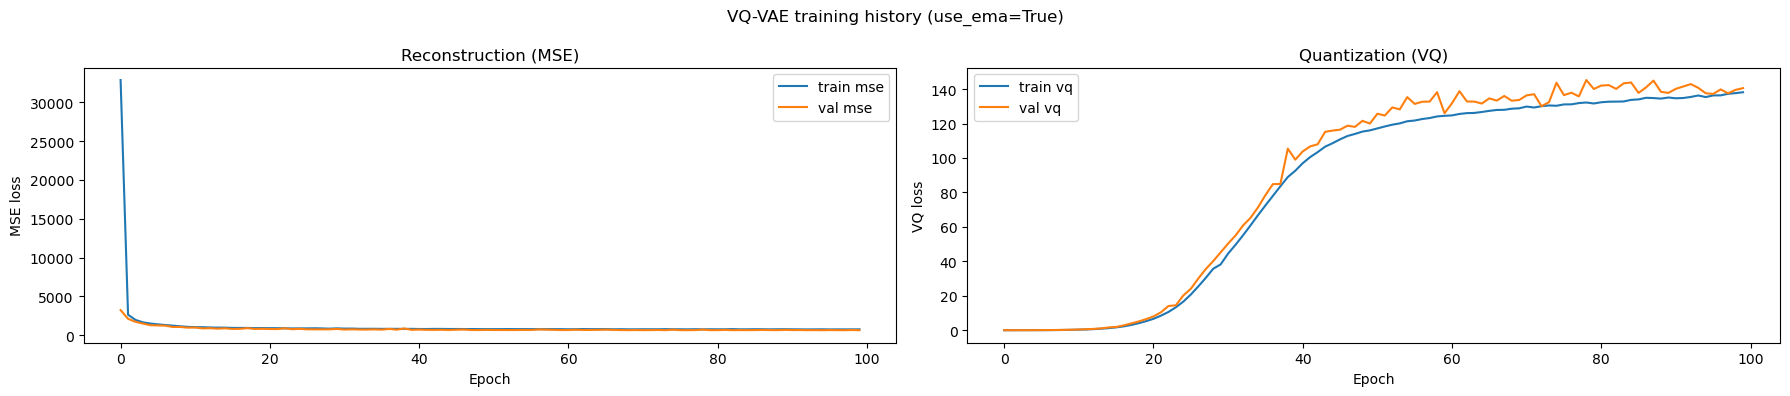

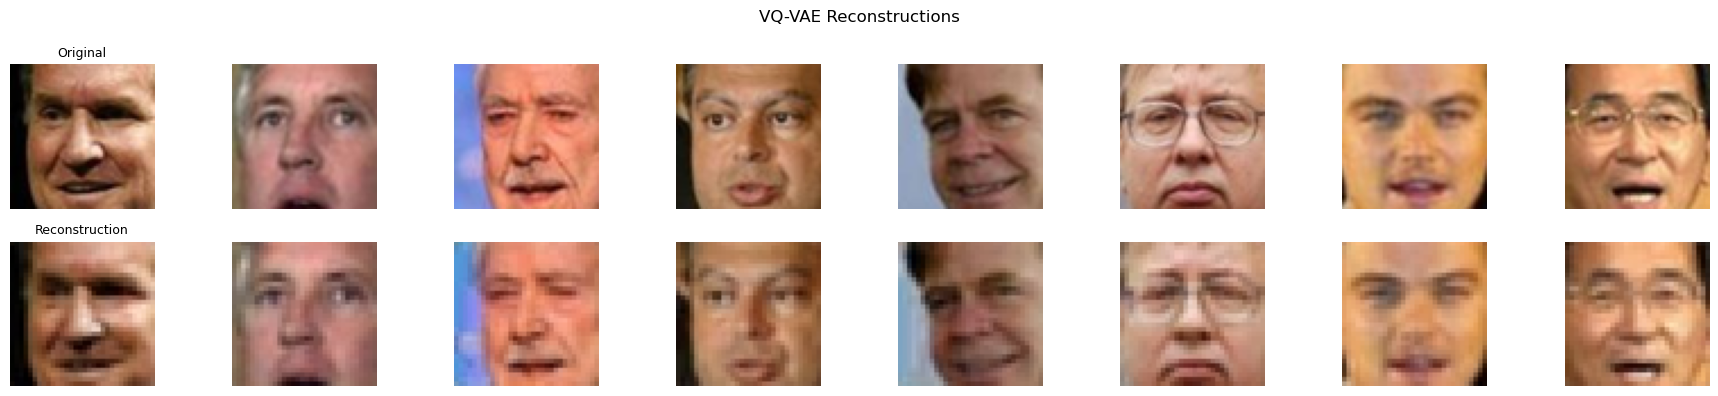

In [11]:
fig, (ax_mse, ax_vq) = plt.subplots(1, 2, figsize=(18, 4))

ax_mse.plot(train_mse_losses, label='train mse')
ax_mse.plot(val_mse_losses,   label='val mse')
ax_mse.set_xlabel('Epoch')
ax_mse.set_ylabel('MSE loss')
ax_mse.set_title('Reconstruction (MSE)')
ax_mse.legend()

ax_vq.plot(train_vq_losses, label='train vq')
ax_vq.plot(val_vq_losses,   label='val vq')
ax_vq.set_xlabel('Epoch')
ax_vq.set_ylabel('VQ loss')
ax_vq.set_title('Quantization (VQ)')
ax_vq.legend()

fig.suptitle(f"VQ-VAE training history (use_ema={USE_EMA})")
plt.tight_layout()
plt.show()

model.eval()
with torch.no_grad():
    sample_batch = next(iter(val_loader)).permute(0, 3, 1, 2).to(device).to(torch.float32) / 255
    reconstruction, _ = model(sample_batch)

n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(18, 4))
for i in range(n_show):
    axes[0, i].imshow(sample_batch[i].cpu().permute(1, 2, 0).numpy().clip(0, 1))
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstruction[i].cpu().permute(1, 2, 0).numpy().clip(0, 1))
    axes[1, i].axis('off')
axes[0, 0].set_title('Original', fontsize=9)
axes[1, 0].set_title('Reconstruction', fontsize=9)
plt.suptitle('VQ-VAE Reconstructions')
plt.tight_layout()
plt.show()

Codebook size:   1024
Codes in use:    1024


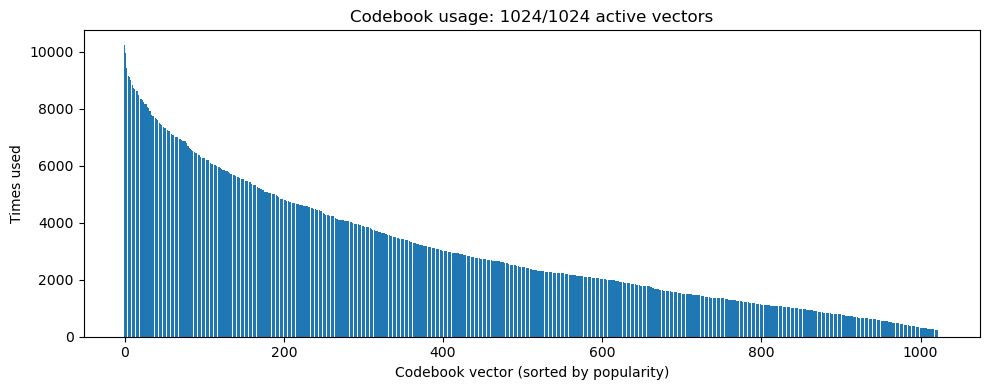

Top-10 codes take 3.1% of all assignments
Median uses: 2351 | max: 10233 | min: 148


In [12]:
model.eval()
all_indices = []
with torch.no_grad():
    for batch in train_loader:
        batch = batch.permute(0, 3, 1, 2).to(device).to(torch.float32) / 255
        z_e, _ = model.encode(batch)
        indices = model.quantize.get_code_indices(z_e)
        all_indices.append(indices.cpu().numpy())
all_indices = np.concatenate(all_indices)

n_e = model.quantize.n_e
unique, counts = np.unique(all_indices, return_counts=True)
print(f'Codebook size:   {n_e}')
print(f'Codes in use:    {len(unique)}')

counts_sorted = np.sort(counts)[::-1]
plt.figure(figsize=(10, 4))
plt.bar(range(len(counts_sorted)), counts_sorted)
plt.xlabel('Codebook vector (sorted by popularity)')
plt.ylabel('Times used')
plt.title(f'Codebook usage: {len(unique)}/{n_e} active vectors')
plt.tight_layout()
plt.show()

print(f'Top-10 codes take {counts_sorted[:10].sum() / counts.sum() * 100:.1f}% of all assignments')
print(f'Median uses: {np.median(counts):.0f} | max: {counts.max()} | min: {counts.min()}')